<img src="logo_UNSAM.jpg" width="180" align="right">

# Trabajo Práctico 4 / TS4 | Romero Marchione, Luz | 15/9/26

<br clear="right">

En esta tarea se analizará el comportamiento de distintos estimadores de amplitud y frecuencia aplicados a una señal senoidal con desintonía aleatoria y ruido gaussiano.

Se compararán las ventanas rectangular, Flattop, Blackman-Harris y Hamming para SNR = 3 dB y SNR = 10 dB, utilizando 200 realizaciones de 1000 muestras.

A partir de los histogramas se realizará un análisis cualitativo y luego se calcularán el sesgo y la varianza de cada estimador para comparar el efecto de la ventana y del nivel de ruido sobre las estimaciones.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Fundamentos teóricos</h2>
</div>

### Señal analizada y desintonía

En esta tarea se trabajará con una señal senoidal contaminada con ruido gaussiano,

$$
x[n]=a_0\sin(\Omega_1 n)+n_a[n],
$$

utilizando $f_s=1000\text{ Hz}$ y $N=1000$ muestras, por lo que la resolución frecuencial es $\Delta f=f_s/N=1\text{ Hz}$. La amplitud se fija en $a_0=\sqrt{2}$ para obtener una potencia senoidal unitaria.

La frecuencia central es $\Omega_0=\pi/2$, equivalente a

$$
f_0=\frac{\Omega_0}{2\pi}f_s=\frac{f_s}{4}=250\text{ Hz},
$$

y la frecuencia real presenta una desintonía aleatoria dada por

$$
\Omega_1=\Omega_0+f_r\frac{2\pi}{N}, \qquad f_r\sim U(-2,2).
$$

El ruido se modela como $n_a\sim\mathcal{N}(0,\sigma^2)$. Como $P_s=1$, para una determinada SNR su potencia se obtiene como

$$
P_n=\frac{1}{10^{SNR/10}}=\sigma^2.
$$

Se realizarán $M=200$ realizaciones independientes para SNR de 3 dB y 10 dB.

### Ventaneo

Como se estudió anteriormente, cuando una senoidal no coincide exactamente con un bin de la DFT aparece **desparramo espectral**. Para modificar este comportamiento se multiplica la señal por una ventana:

$$
x_w[n]=x[n]\,w[n].
$$

La multiplicación en el dominio temporal equivale a una convolución en frecuencia, por lo que cada ventana modifica la forma del espectro.

En este trabajo se analizarán las ventanas **rectangular, Flattop, Blackman-Harris y Hamming**. Cada una presenta un compromiso diferente entre el ancho del lóbulo principal y el nivel de los lóbulos laterales. Un lóbulo principal más angosto favorece la resolución en frecuencia, mientras que un lóbulo más ancho y plano puede hacer que la estimación de amplitud sea menos sensible a pequeñas desintonías.

Por lo tanto, la elección de la ventana implica un **trade-off** y su conveniencia depende del parámetro que se desea estimar.

### Estimadores de amplitud y frecuencia

Un **estimador** permite obtener una aproximación de un parámetro desconocido a partir de los datos disponibles.

Para estimar la amplitud se evaluará el módulo de la transformada de la señal ventaneada en la frecuencia central:

$$
\hat a_1^{\,i}=|X_w^i(\Omega_0)|.
$$

De esta manera se analiza cómo cambia la amplitud medida en $\Omega_0$ cuando la frecuencia real $\Omega_1$ se desplaza respecto de ella.

Para estimar la frecuencia se buscará la posición del máximo del espectro:

$$
\hat\Omega_1^{\,i}=\arg\max_{\Omega}|X_w^i(\Omega)|.
$$

Por lo tanto, este estimador selecciona el bin en el que el módulo de la DFT alcanza su máximo.

### Sesgo y varianza

A partir de las 200 realizaciones se analizará estadísticamente el comportamiento de cada estimador. Su **valor esperado** se aproximará mediante la media muestral:

$$
E[\hat\theta]\approx\frac{1}{M}\sum_{j=0}^{M-1}\hat\theta_j.
$$

El **sesgo** mide la diferencia entre el valor medio estimado y el valor verdadero,

$$
s_{\hat\theta}=E[\hat\theta]-\theta,
$$

mientras que la **varianza** mide la dispersión de las estimaciones alrededor de su media,

$$
v_{\hat\theta}=E\left[(\hat\theta-E[\hat\theta])^2\right].
$$

Un sesgo cercano a cero indica un bajo error sistemático, mientras que una menor varianza corresponde a estimaciones más concentradas y, por lo tanto, más precisas.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Desarrollo</h2>
</div>

Defino librerías y parametros

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import windows

fs = 1000          # Frecuencia de muestreo [Hz]
N = 1000           # Cantidad de muestras
r = 200            # Cantidad de realizaciones

a0 = np.sqrt(2)    # Amplitud para potencia de la senoidal = 1 W
mu = 0             # Media del ruido

df = fs / N

# Eje de frecuencias de la FFT positiva
bins = np.arange(0, N//2) * df

Genero las 200 realizaciones

In [16]:
om0 = N//4 # bin k0 asociado a Ω0 = π/2

# Desintonía aleatoria de cada realización
fr = np.random.uniform(-2, 2, r)

# Frecuencia de cada una de las 200 realizaciones
om1 = om0 + fr

# Conversión a Hz
om1_df = om1 * df

# Las 200 frecuencias se ubican horizontalmente
om1_fila = om1_df.reshape((1, r))

# Las 1000 muestras se ubican verticalmente
n = np.arange(0, N, 1)
n_col = n.reshape((N, 1))

# Matriz 1000 x 200
# Cada columna es una realización
sen = a0 * np.sin(2*np.pi*om1_fila*n_col/fs)

Genero los ruidos aleatorios tanto para SNR = 3 dB y 10 dB

In [17]:
# SNR = 3 dB
SNR_3 = 3

# Como Pseñal = 1 W:
# SNR = Pseñal / Pruido
# Como el ruido es gaussiano de media cero:
# Pruido = varianza = desviación estándar^2

desv_est_3 = np.sqrt(10**(-SNR_3/10))

na_3 = np.random.normal(mu, desv_est_3, (N, r))

x_3 = sen + na_3

# SNR = 10 dB

SNR_10 = 10

desv_est_10 = np.sqrt(10**(-SNR_10/10))

na_10 = np.random.normal(mu, desv_est_10, (N, r))

x_10 = sen + na_10

Defino ventanas y aplico FFT

In [18]:
# La rectangular queda implícita:
# x_rect = x * 1 = x

w_flat = windows.flattop(N)
w_bh = windows.blackmanharris(N)
w_hamm = windows.hamming(N)


# Como las ventanas son vectores debo pasarlas a columnas (1000,1) para aplicarlas a las 200 realizaciones

w_flat_col = w_flat.reshape((N, 1))
w_bh_col = w_bh.reshape((N, 1))
w_hamm_col = w_hamm.reshape((N, 1))


# axis=0 calcula la FFT verticalmente
# una FFT de 1000 muestras por cada una de las 200 columnas

# SNR = 3 dB

fft_rect_3 = (1/N) * np.fft.fft(x_3, axis=0)

x_flat_3 = x_3 * w_flat_col
fft_flat_3 = (1/N) * np.fft.fft(x_flat_3, axis=0)

x_bh_3 = x_3 * w_bh_col
fft_bh_3 = (1/N) * np.fft.fft(x_bh_3, axis=0)

x_hamm_3 = x_3 * w_hamm_col
fft_hamm_3 = (1/N) * np.fft.fft(x_hamm_3, axis=0)


# SNR = 10 dB

fft_rect_10 = (1/N) * np.fft.fft(x_10, axis=0)

x_flat_10 = x_10 * w_flat_col
fft_flat_10 = (1/N) * np.fft.fft(x_flat_10, axis=0)

x_bh_10 = x_10 * w_bh_col
fft_bh_10 = (1/N) * np.fft.fft(x_bh_10, axis=0)

x_hamm_10 = x_10 * w_hamm_col
fft_hamm_10 = (1/N) * np.fft.fft(x_hamm_10, axis=0)

Visualizo las ventanas en tiempo y frecuencia

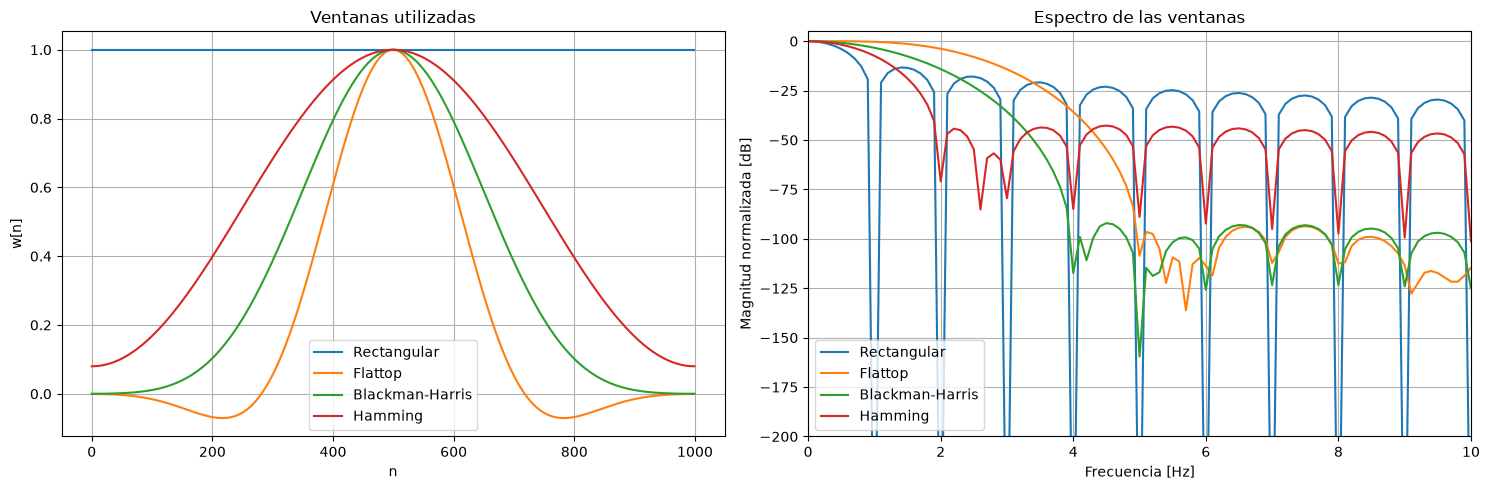

In [19]:
w_rect = np.ones(N) #para visualizarlo
fig,ax = plt.subplots(1,2,figsize=(15,5))

# Ventanas en tiempo
ax[0].plot(n,w_rect,color='tab:blue',label='Rectangular')
ax[0].plot(n,w_flat,color='tab:orange',label='Flattop')
ax[0].plot(n,w_bh,color='tab:green',label='Blackman-Harris')
ax[0].plot(n,w_hamm,color='tab:red',label='Hamming')

ax[0].set_xlabel('n')
ax[0].set_ylabel('w[n]')
ax[0].set_title('Ventanas utilizadas')
ax[0].legend()
ax[0].grid()

# Espectro de las ventanas
Nfft = 10*N
f = np.arange(Nfft//2)*fs/Nfft

W_rect = np.fft.fft(w_rect,Nfft)
W_flat = np.fft.fft(w_flat,Nfft)
W_bh = np.fft.fft(w_bh,Nfft)
W_hamm = np.fft.fft(w_hamm,Nfft)

rect_db = 20*np.log10(np.abs(W_rect[:Nfft//2])+1e-12)
flat_db = 20*np.log10(np.abs(W_flat[:Nfft//2])+1e-12)
bh_db = 20*np.log10(np.abs(W_bh[:Nfft//2])+1e-12)
hamm_db = 20*np.log10(np.abs(W_hamm[:Nfft//2])+1e-12)

#para normalizar y que queden comparables los lobulos ppales
rect_db = rect_db - np.max(rect_db)
flat_db = flat_db - np.max(flat_db)
bh_db = bh_db - np.max(bh_db)
hamm_db = hamm_db - np.max(hamm_db)

ax[1].plot(f,rect_db,color='tab:blue',label='Rectangular')
ax[1].plot(f,flat_db,color='tab:orange',label='Flattop')
ax[1].plot(f,bh_db,color='tab:green',label='Blackman-Harris')
ax[1].plot(f,hamm_db,color='tab:red',label='Hamming')

ax[1].set_xlim(0,10)
ax[1].set_ylim(-200,5)
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('Magnitud normalizada [dB]')
ax[1].set_title('Espectro de las ventanas')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

#### Características de las ventanas

Se obseravn las cuatro ventanas utilizadas tanto en el dominio temporal como en frecuencia. El objetivo de estos gráficos es verificar la forma de las ventanas implementadas y observar sus principales características espectrales antes de aplicarlas sobre las señales.

Se observa que cada ventana presenta un lóbulo principal de diferente ancho y una distinta atenuación de los lóbulos laterales. La rectangular posee el lóbulo principal más angosto, mientras que Flattop presenta el más ancho y una región superior considerablemente más plana. Hamming y Blackman-Harris presentan comportamientos intermedios, aunque esta última produce una mayor atenuación de los lóbulos laterales.

A continuación se analiza el efecto de cada ventana sobre el espectro de una misma realización de la señal y, posteriormente, sobre el conjunto de las 200 realizaciones utilizadas en el experimento.

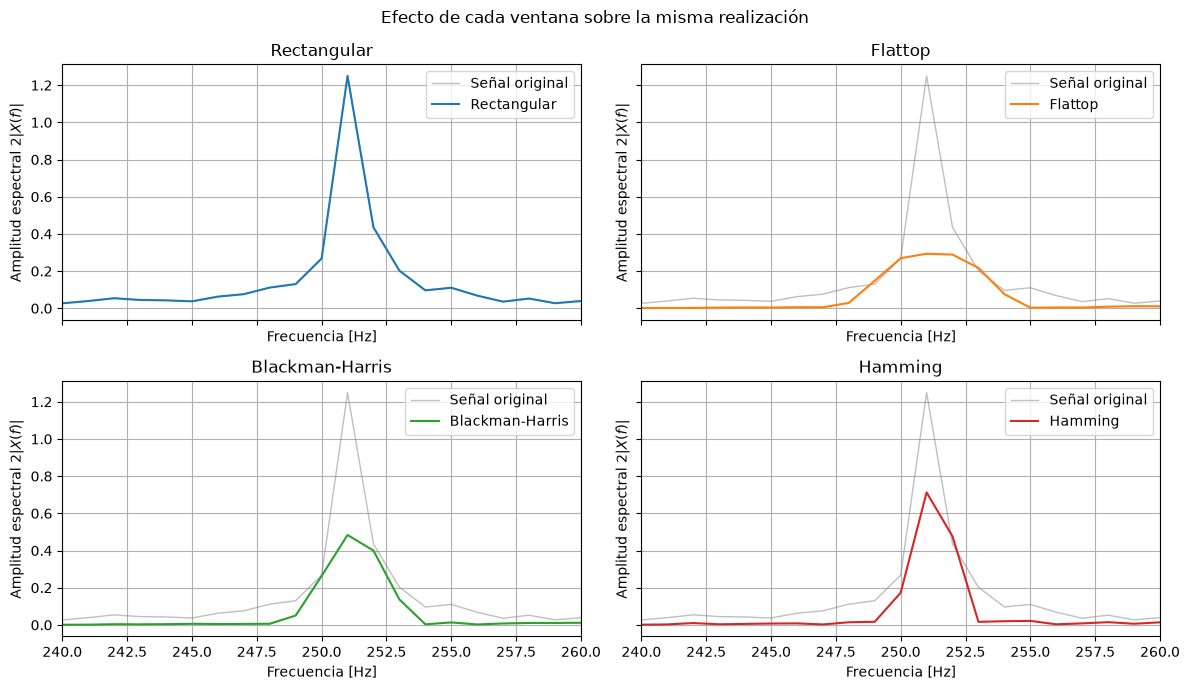

In [20]:
j = 0 #realizacion 0

fig,ax = plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

# Señal original, sin ventana
X_original = 2*np.abs(fft_rect_10[:N//2,j])

# Rectangular
ax[0,0].plot(bins,X_original,color='gray',linewidth=1,alpha=0.5,label='Señal original')
ax[0,0].plot(bins,2*np.abs(fft_rect_10[:N//2,j]),color='tab:blue',label='Rectangular')
ax[0,0].set_title('Rectangular')

# Flattop
ax[0,1].plot(bins,X_original,color='gray',linewidth=1,alpha=0.5,label='Señal original')
ax[0,1].plot(bins,2*np.abs(fft_flat_10[:N//2,j]),color='tab:orange',label='Flattop')
ax[0,1].set_title('Flattop')

# Blackman-Harris
ax[1,0].plot(bins,X_original,color='gray',linewidth=1,alpha=0.5,label='Señal original')
ax[1,0].plot(bins,2*np.abs(fft_bh_10[:N//2,j]),color='tab:green',label='Blackman-Harris')
ax[1,0].set_title('Blackman-Harris')

# Hamming
ax[1,1].plot(bins,X_original,color='gray',linewidth=1,alpha=0.5,label='Señal original')
ax[1,1].plot(bins,2*np.abs(fft_hamm_10[:N//2,j]),color='tab:red',label='Hamming')
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlim(240,260)
    graf.set_xlabel('Frecuencia [Hz]')
    graf.set_ylabel(r'Amplitud espectral $2|X(f)|$')
    graf.legend()
    graf.grid()

fig.suptitle('Efecto de cada ventana sobre la misma realización')
plt.tight_layout()
plt.show()

Grafico amplitud unicamente para SNR=3 dB para visualizar como se ve la aplicación de cada ventana para las 200 realizaciones

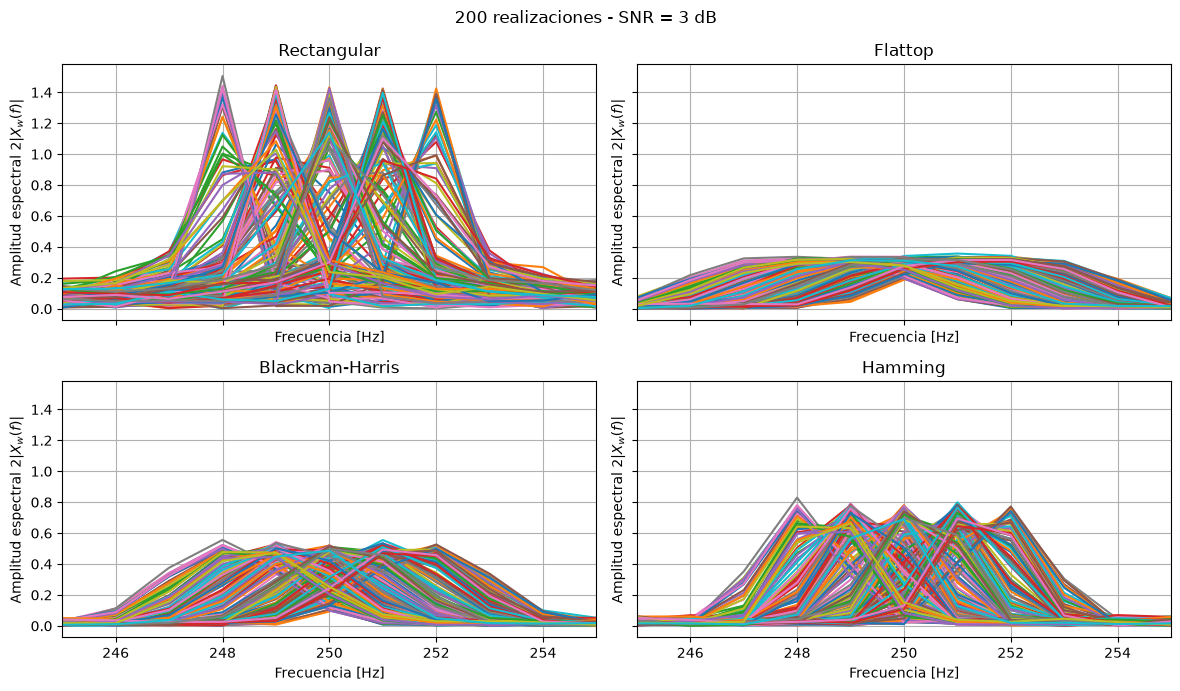

In [34]:
fig, ax = plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

ax[0,0].plot(bins,2*np.abs(fft_rect_3[:N//2,:]))
ax[0,0].set_title('Rectangular')

ax[0,1].plot(bins,2*np.abs(fft_flat_3[:N//2,:]))
ax[0,1].set_title('Flattop')

ax[1,0].plot(bins,2*np.abs(fft_bh_3[:N//2,:]))
ax[1,0].set_title('Blackman-Harris')

ax[1,1].plot(bins,2*np.abs(fft_hamm_3[:N//2,:]))
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlim(245,255)
    graf.set_xlabel('Frecuencia [Hz]')
    graf.set_ylabel(r'Amplitud espectral $2|X_w(f)|$')
    graf.grid()

fig.suptitle('200 realizaciones - SNR = 3 dB')
plt.tight_layout()
plt.show()

Grafico amplitud en dB para ambos SNR para comparar todos los parámetros

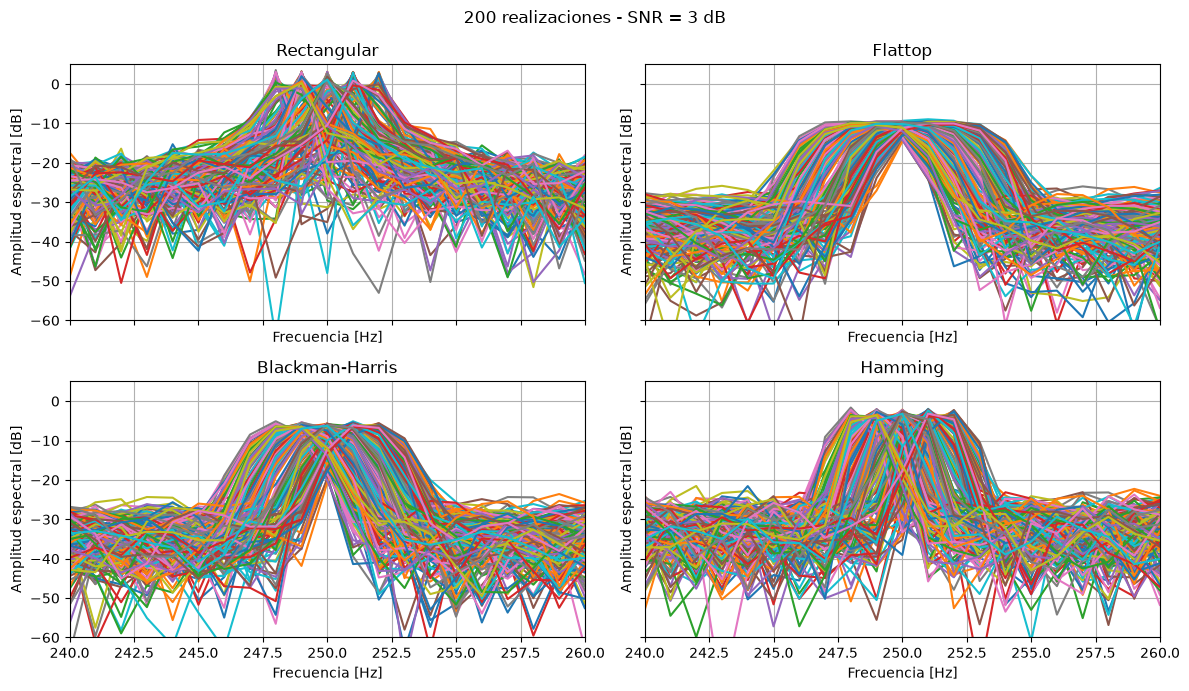

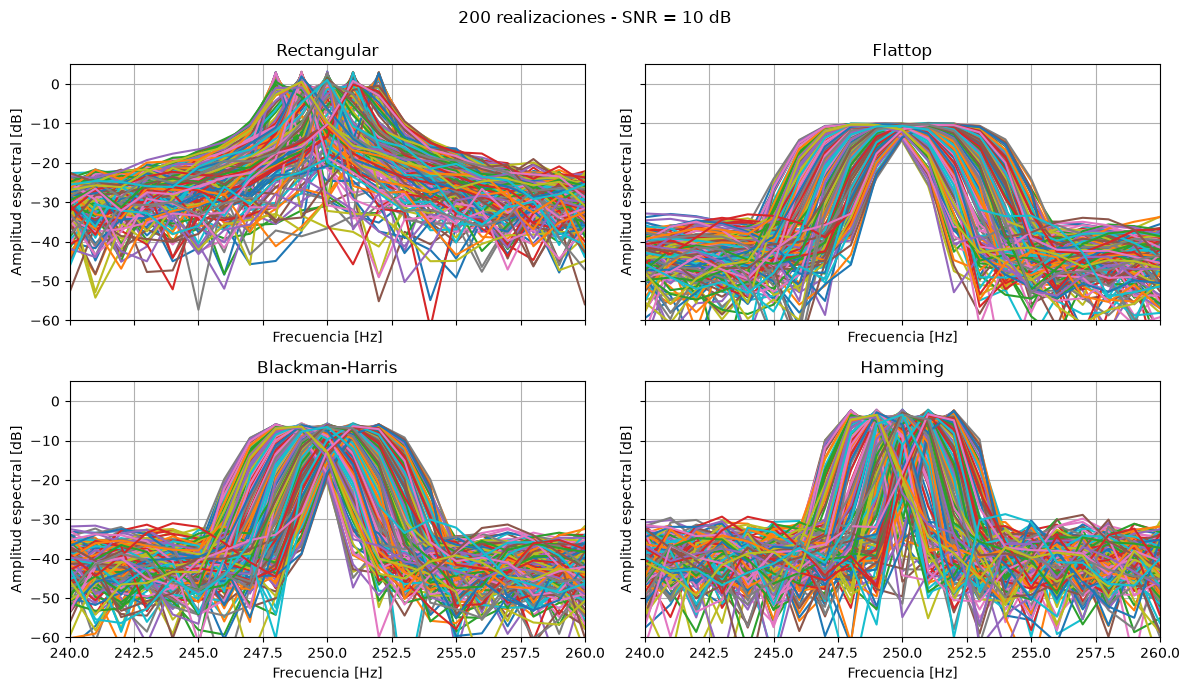

In [33]:
# 200 REALIZACIONES - SNR = 3 dB - ESCALA EN dB

fig,ax=plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

ax[0,0].plot(bins,20*np.log10(2*np.abs(fft_rect_3[:N//2,:])+1e-12))
ax[0,0].set_title('Rectangular')

ax[0,1].plot(bins,20*np.log10(2*np.abs(fft_flat_3[:N//2,:])+1e-12))
ax[0,1].set_title('Flattop')

ax[1,0].plot(bins,20*np.log10(2*np.abs(fft_bh_3[:N//2,:])+1e-12))
ax[1,0].set_title('Blackman-Harris')

ax[1,1].plot(bins,20*np.log10(2*np.abs(fft_hamm_3[:N//2,:])+1e-12))
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlim(240,260)
    graf.set_ylim(-60,5)
    graf.set_xlabel('Frecuencia [Hz]')
    graf.set_ylabel('Amplitud espectral [dB]')
    graf.grid()

fig.suptitle('200 realizaciones - SNR = 3 dB')
plt.tight_layout()
plt.show()

print("=" * 151)
print("=" * 151)
# 200 REALIZACIONES - SNR = 10 dB - ESCALA EN dB

fig,ax=plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

ax[0,0].plot(bins,20*np.log10(2*np.abs(fft_rect_10[:N//2,:])+1e-12))
ax[0,0].set_title('Rectangular')

ax[0,1].plot(bins,20*np.log10(2*np.abs(fft_flat_10[:N//2,:])+1e-12))
ax[0,1].set_title('Flattop')

ax[1,0].plot(bins,20*np.log10(2*np.abs(fft_bh_10[:N//2,:])+1e-12))
ax[1,0].set_title('Blackman-Harris')

ax[1,1].plot(bins,20*np.log10(2*np.abs(fft_hamm_10[:N//2,:])+1e-12))
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlim(240,260)
    graf.set_ylim(-60,5)
    graf.set_xlabel('Frecuencia [Hz]')
    graf.set_ylabel('Amplitud espectral [dB]')
    graf.grid()

fig.suptitle('200 realizaciones - SNR = 10 dB')
plt.tight_layout()
plt.show()

#### Efecto del ventaneo sobre las señales

Al aplicar las distintas ventanas sobre una misma realización puede observarse directamente cómo modifican su espectro. La ventana rectangular no produce cambios, ya que equivale a multiplicar la señal por uno. En cambio, las demás ventanas modifican la forma del pico espectral, ensanchándolo en distinta medida y reduciendo los lóbulos laterales.

Este comportamiento puede relacionarse con el espectro de cada ventana. Como la multiplicación en el dominio temporal equivale a una convolución en frecuencia, el espectro de la senoide queda modificado según la forma completa del espectro de la ventana, incluyendo su lóbulo principal y sus lóbulos laterales.Por este motivo, la ventana Flattop genera un pico más ancho y plano, Blackman-Harris también produce un ensanchamiento importante, mientras que Hamming y rectangular mantienen picos más angostos.

Este mismo comportamiento se observa al representar las 200 realizaciones. Debido a que la desintonía aleatoria permite frecuencias entre aproximadamente 248 Hz y 252 Hz, los máximos espectrales se concentran principalmente alrededor de estos cinco bins. Al no coincidir siempre la frecuencia real con un bin de la DFT, aparece además desparramo espectral hacia las frecuencias vecinas.

En la zona cercana a la frecuencia de la senoide domina principalmente el lóbulo principal, por lo que la ventana Flattop genera un pico más ancho y plano, Blackman-Harris también produce un ensanchamiento importante, mientras que Hamming y rectangular mantienen picos más angostos. Los lóbulos laterales también están presentes, aunque poseen menor amplitud y resultan menos visibles en la escala utilizada.

Las ventanas rectangular y Hamming mantienen máximos relativamente angostos, mientras que Flattop y Blackman-Harris distribuyen la componente de la señal sobre un rango mayor de frecuencias. En particular, Flattop produce una región superior considerablemente más plana.

Al comparar SNR = 3 dB y SNR = 10 dB, la forma de los picos principales se mantiene prácticamente igual, pero al representar los espectros en dB se observa con mayor claridad una diferencia en el piso de ruido. Para SNR = 10 dB el piso se encuentra varios decibeles por debajo del correspondiente a SNR = 3 dB, lo cual es coherente con la menor potencia de ruido presente. Como entre ambos casos existe una diferencia de SNR de 7dB, es esperable observar una reducción del piso de ruido de ese orden. De todas formas, para determinar cuánto afecta este cambio de SNR al desempeño de los estimadores, su influencia será comparada posteriormente mediante los histogramas, el sesgo y la varianza.

#### Calculo estimadores de amplitud para cada ventana:

In [23]:
# Se evalúa la FFT en om0 = N/4 = bin 250
# Se multiplica por 2 porque trabajamos con el espectro positivo de una señal real

# SNR = 3 dB

a1_rect_3 = 2 * np.abs(fft_rect_3[om0, :])
a1_flat_3 = 2 * np.abs(fft_flat_3[om0, :])
a1_bh_3 = 2 * np.abs(fft_bh_3[om0, :])
a1_hamm_3 = 2 * np.abs(fft_hamm_3[om0, :])

# SNR = 10 dB

a1_rect_10 = 2 * np.abs(fft_rect_10[om0, :])
a1_flat_10 = 2 * np.abs(fft_flat_10[om0, :])
a1_bh_10 = 2 * np.abs(fft_bh_10[om0, :])
a1_hamm_10 = 2 * np.abs(fft_hamm_10[om0, :])

Grafico Histograma de amplitud para SNR=3dB y SNR=10dB y los grafico en un mismo subplot para mejorar su comparación:

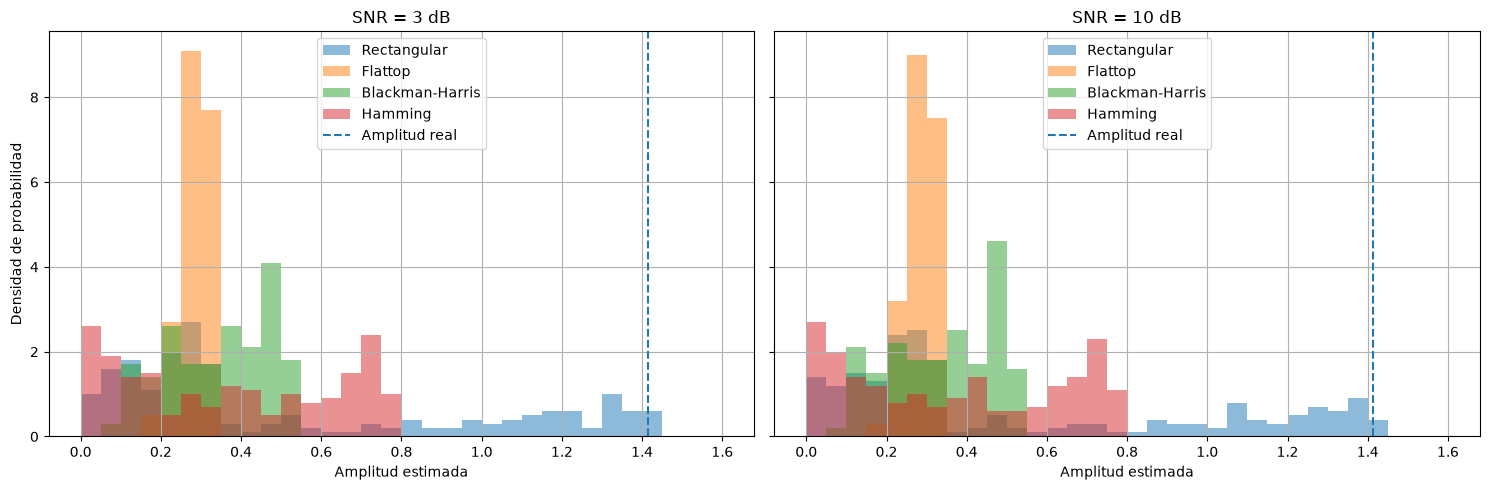

In [24]:
eje_amp = np.arange(0, 1.65, 0.05)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

# SNR = 3 dB
ax[0].hist(a1_rect_3, bins=eje_amp, density=True, alpha=0.5, label='Rectangular')
ax[0].hist(a1_flat_3, bins=eje_amp, density=True, alpha=0.5, label='Flattop')
ax[0].hist(a1_bh_3, bins=eje_amp, density=True, alpha=0.5, label='Blackman-Harris')
ax[0].hist(a1_hamm_3, bins=eje_amp, density=True, alpha=0.5, label='Hamming')
ax[0].axvline(a0, linestyle='--', label='Amplitud real')
ax[0].set_xlabel('Amplitud estimada')
ax[0].set_ylabel('Densidad de probabilidad')
ax[0].set_title('SNR = 3 dB')
ax[0].legend()
ax[0].grid()

# SNR = 10 dB
ax[1].hist(a1_rect_10, bins=eje_amp, density=True, alpha=0.5, label='Rectangular')
ax[1].hist(a1_flat_10, bins=eje_amp, density=True, alpha=0.5, label='Flattop')
ax[1].hist(a1_bh_10, bins=eje_amp, density=True, alpha=0.5, label='Blackman-Harris')
ax[1].hist(a1_hamm_10, bins=eje_amp, density=True, alpha=0.5, label='Hamming')
ax[1].axvline(a0, linestyle='--', label='Amplitud real')
ax[1].set_xlabel('Amplitud estimada')
ax[1].set_title('SNR = 10 dB')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

### Análisis del estimador de amplitud

Los histogramas representan la distribución de las 200 estimaciones de amplitud obtenidas para cada ventana. Al estar normalizados, el área de cada distribución es unitaria.

Se pueden analizar dos características diferentes: la posición de la distribución y su dispersión.

El desplazamiento de las distribuciones respecto del valor real $
a_0=\sqrt{2}
$
indica la presencia de sesgo. En este caso, las estimaciones se encuentran desplazadas hacia valores menores que el verdadero, por lo que los estimadores presentan un sesgo negativo.

Por otro lado, el ancho de cada distribución está relacionado con la varianza del estimador. Una distribución más angosta y concentrada implica menor varianza y, por lo tanto, mayor precisión. Como todos los histogramas tienen área unitaria, una distribución más concentrada tiende también a presentar una mayor altura.

Se observa que la ventana Flattop produce una distribución más concentrada, mientras que la rectangular presenta una mayor dispersión. Esto coincide con lo esperado a partir de la forma de sus lóbulos principales: la región más plana de Flattop hace que la amplitud evaluada en $f_0$ sea menos sensible a la desintonía, mientras que el lóbulo angosto de la rectangular provoca mayores variaciones en la amplitud estimada.

Es importante distinguir sesgo de varianza. Un sesgo sistemático puede corregirse mediante una calibración, mientras que una elevada dispersión entre realizaciones no puede eliminarse mediante una simple corrección constante. Prefiero tener buena varianza y mal sesgo ya que a este último lo puedo corregir.

Por ejemplo, una corrección del sesgo podría realizarse como  $
\hat a_{1,\text{cal}}=
\hat a_1-E[\hat a_1]+a_0,
$ de forma que el valor medio del estimador coincida con $\sqrt{2}$ sin modificar su varianza.

Las diferencias observadas entre los histogramas para SNR = 3 dB y SNR = 10 dB no son lo suficientemente claras como para evaluar correctamente el efecto del cambio de SNR. Cualitativamente se podria decir que variaron poco, la unica diferencia notoria está en el pico de la ventana flattop. Por este motivo, dicha comparación se realizará cuantitativamente a partir de las tablas de sesgo y varianza.

#### Calculo estimadores de frecuencia para cada ventana:

In [25]:
# Para cada una de las 200 realizaciones se busca el bin donde el módulo de la FFT alcanza su máximo.
# bins[] convierte el número de bin a frecuencia en Hz.

# SNR = 3 dB
est_frec_rect_3 = bins[np.argmax(np.abs(fft_rect_3[0:N//2, :]), axis=0)]
est_frec_flat_3 = bins[np.argmax(np.abs(fft_flat_3[0:N//2, :]), axis=0)]
est_frec_bh_3 = bins[np.argmax(np.abs(fft_bh_3[0:N//2, :]), axis=0)]
est_frec_hamm_3 = bins[np.argmax(np.abs(fft_hamm_3[0:N//2, :]), axis=0)]

# SNR = 10 dB
est_frec_rect_10 = bins[np.argmax(np.abs(fft_rect_10[0:N//2, :]), axis=0)]
est_frec_flat_10 = bins[np.argmax(np.abs(fft_flat_10[0:N//2, :]), axis=0)]
est_frec_bh_10 = bins[np.argmax(np.abs(fft_bh_10[0:N//2, :]), axis=0)]
est_frec_hamm_10 = bins[np.argmax(np.abs(fft_hamm_10[0:N//2, :]), axis=0)]

Grafico estimadores de frecuencia:

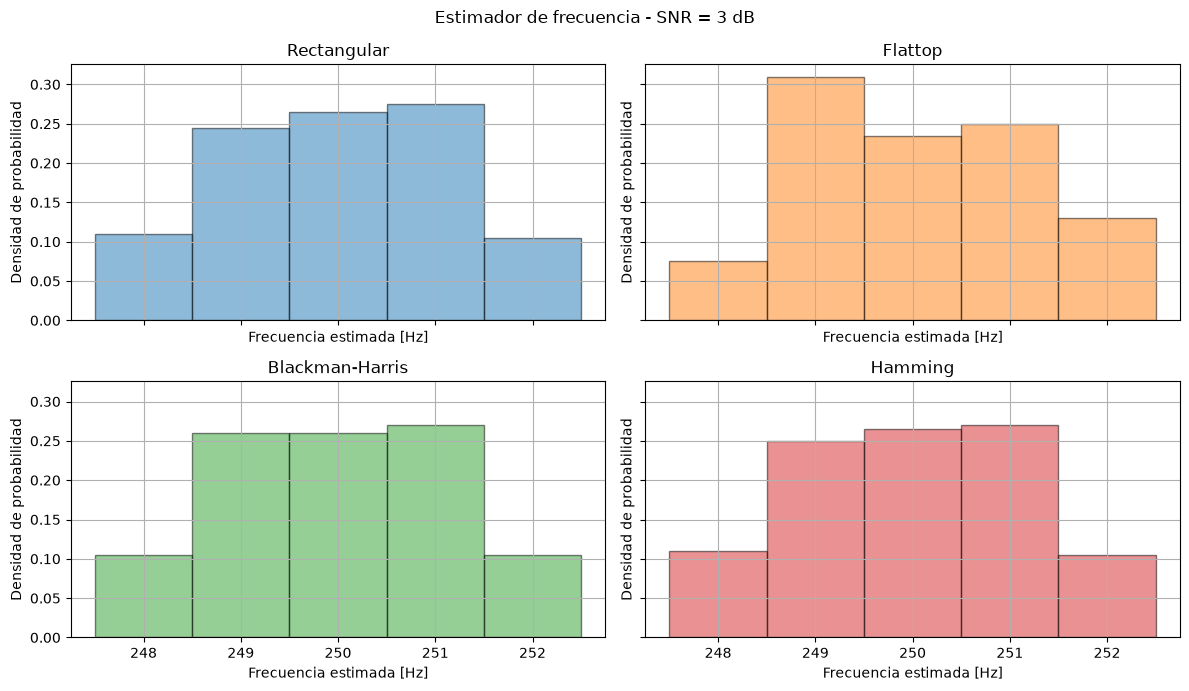

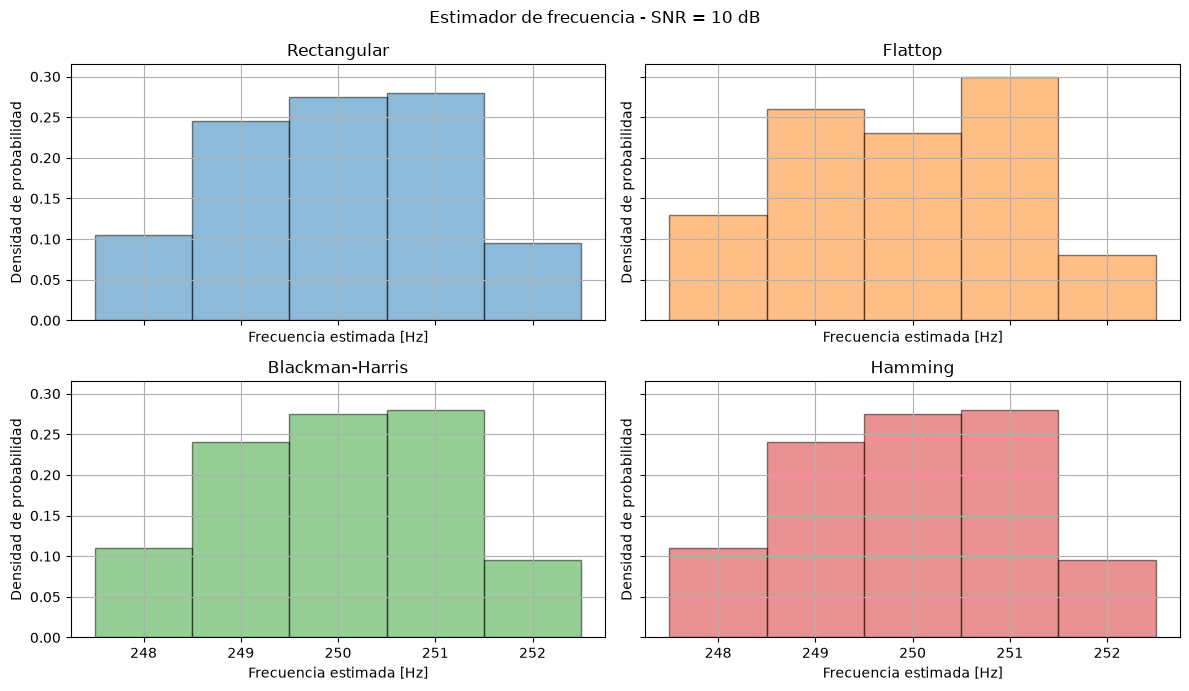

In [26]:
eje_frec = np.arange(247.5,253.5,1)

fig,ax = plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

ax[0,0].hist(est_frec_rect_3,bins=eje_frec,density=True,color='tab:blue',alpha=0.5,edgecolor='black')
ax[0,0].set_title('Rectangular')

ax[0,1].hist(est_frec_flat_3,bins=eje_frec,density=True,color='tab:orange',alpha=0.5,edgecolor='black')
ax[0,1].set_title('Flattop')

ax[1,0].hist(est_frec_bh_3,bins=eje_frec,density=True,color='tab:green',alpha=0.5,edgecolor='black')
ax[1,0].set_title('Blackman-Harris')

ax[1,1].hist(est_frec_hamm_3,bins=eje_frec,density=True,color='tab:red',alpha=0.5,edgecolor='black')
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlabel('Frecuencia estimada [Hz]')
    graf.set_ylabel('Densidad de probabilidad')
    graf.grid()

fig.suptitle('Estimador de frecuencia - SNR = 3 dB')
plt.tight_layout()
plt.show()
print("=" * 151)
print("=" * 151)
fig,ax = plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)

ax[0,0].hist(est_frec_rect_10,bins=eje_frec,density=True,color='tab:blue',alpha=0.5,edgecolor='black')
ax[0,0].set_title('Rectangular')

ax[0,1].hist(est_frec_flat_10,bins=eje_frec,density=True,color='tab:orange',alpha=0.5,edgecolor='black')
ax[0,1].set_title('Flattop')

ax[1,0].hist(est_frec_bh_10,bins=eje_frec,density=True,color='tab:green',alpha=0.5,edgecolor='black')
ax[1,0].set_title('Blackman-Harris')

ax[1,1].hist(est_frec_hamm_10,bins=eje_frec,density=True,color='tab:red',alpha=0.5,edgecolor='black')
ax[1,1].set_title('Hamming')

for graf in ax.flat:
    graf.set_xlabel('Frecuencia estimada [Hz]')
    graf.set_ylabel('Densidad de probabilidad')
    graf.grid()

fig.suptitle('Estimador de frecuencia - SNR = 10 dB')
plt.tight_layout()
plt.show()

#### Análisis del estimador de frecuencia

Como la resolución frecuencial es $\Delta f=1\text{ Hz}$, el estimador de frecuencia solo puede tomar valores correspondientes a los bins de la DFT. Por este motivo, las estimaciones se concentran principalmente en 248, 249, 250, 251 y 252 Hz. En el histograma, cada barra se encuentra centrada en uno de estos valores; por ejemplo, el intervalo entre 248.5 Hz y 249.5 Hz representa todas las realizaciones cuya frecuencia estimada fue exactamente 249 Hz.

Los histogramas se encuentran normalizados mediante density=True. Como el ancho de cada intervalo es de $1\text{ Hz}$, la altura de cada barra coincide en este caso con la fracción de las 200 realizaciones que produjo dicha estimación. Por ejemplo, una altura de 0.25 corresponde aproximadamente a 50 realizaciones.

La menor altura de las barras correspondientes a 248 Hz y 252 Hz se relaciona con el rango de frecuencias posibles. Como $f_r\sim U(-2,2)$ y $\Delta f=1\text{ Hz}$, la frecuencia real se distribuye uniformemente entre 248 Hz y 252 Hz. Los bins interiores reciben frecuencias provenientes de un intervalo de aproximadamente $1\text{ Hz}$, mientras que los bins extremos reciben solamente un intervalo de $0.5\text{ Hz}$. Por lo tanto, es esperable que estos últimos aparezcan aproximadamente la mitad de las veces.

Al comparar los histogramas de las distintas ventanas no se observan diferencias significativas a simple vista. Las distribuciones presentan formas muy similares y las frecuencias estimadas se concentran prácticamente en los mismos bins. Esto sugiere que el estimador de frecuencia es poco sensible a la ventana utilizada. De todas formas, esta observación cualitativa se completará posteriormente mediante los valores de sesgo y, principalmente, de varianza obtenidos en las tablas.

Al comparar SNR = 3 dB y SNR = 10 dB tampoco se distinguen cambios importantes en los histogramas. En ambos casos, el máximo de la FFT continúa localizándose prácticamente en los mismos bins, por lo que la diferencia en el nivel de ruido no se refleja claramente en la frecuencia seleccionada por el estimador. Por este motivo, el efecto del cambio de SNR también se evaluará cuantitativamente a partir de las tablas.

In [27]:
# SNR = 3 dB

print('SNR = 3 dB')
print('Ventana\t\t sa\t\t va\t\t sf [Hz]\t vf [Hz²]')
print('--------------------------------------------------------------------------')
print('Rectangular\t', round(np.mean(a1_rect_3)-a0,6), '\t', round(np.var(a1_rect_3),6), '\t', round(np.mean(est_frec_rect_3-om1_df),6), '\t', round(np.var(est_frec_rect_3),6))
print('Flattop\t\t', round(np.mean(a1_flat_3)-a0,6), '\t', round(np.var(a1_flat_3),6), '\t', round(np.mean(est_frec_flat_3-om1_df),6), '\t', round(np.var(est_frec_flat_3),6))
print('Blackman-Harris\t', round(np.mean(a1_bh_3)-a0,6), '\t', round(np.var(a1_bh_3),6), '\t', round(np.mean(est_frec_bh_3-om1_df),6), '\t', round(np.var(est_frec_bh_3),6))
print('Hamming\t\t', round(np.mean(a1_hamm_3)-a0,6), '\t', round(np.var(a1_hamm_3),6), '\t', round(np.mean(est_frec_hamm_3-om1_df),6), '\t', round(np.var(est_frec_hamm_3),6))


# SNR = 10 dB

print('\nSNR = 10 dB')
print('Ventana\t\t sa\t\t va\t\t sf [Hz]\t vf [Hz²]')
print('--------------------------------------------------------------------------')
print('Rectangular\t', round(np.mean(a1_rect_10)-a0,6), '\t', round(np.var(a1_rect_10),6), '\t', round(np.mean(est_frec_rect_10-om1_df),6), '\t', round(np.var(est_frec_rect_10),6))
print('Flattop\t\t', round(np.mean(a1_flat_10)-a0,6), '\t', round(np.var(a1_flat_10),6), '\t', round(np.mean(est_frec_flat_10-om1_df),6), '\t', round(np.var(est_frec_flat_10),6))
print('Blackman-Harris\t', round(np.mean(a1_bh_10)-a0,6), '\t', round(np.var(a1_bh_10),6), '\t', round(np.mean(est_frec_bh_10-om1_df),6), '\t', round(np.var(est_frec_bh_10),6))
print('Hamming\t\t', round(np.mean(a1_hamm_10)-a0,6), '\t', round(np.var(a1_hamm_10),6), '\t', round(np.mean(est_frec_hamm_10-om1_df),6), '\t', round(np.var(est_frec_hamm_10),6))

SNR = 3 dB
Ventana		 sa		 va		 sf [Hz]	 vf [Hz²]
--------------------------------------------------------------------------
Rectangular	 -0.886858 	 0.209896 	 0.025405 	 1.3796
Flattop		 -1.130584 	 0.001075 	 0.055405 	 1.3775
Blackman-Harris	 -1.071175 	 0.016578 	 0.015405 	 1.3699
Hamming		 -1.039628 	 0.067961 	 0.015405 	 1.3799

SNR = 10 dB
Ventana		 sa		 va		 sf [Hz]	 vf [Hz²]
--------------------------------------------------------------------------
Rectangular	 -0.889809 	 0.209715 	 0.020405 	 1.324775
Flattop		 -1.133648 	 0.00098 	 -0.054595 	 1.3964
Blackman-Harris	 -1.074916 	 0.016787 	 0.015405 	 1.3399
Hamming		 -1.045209 	 0.069388 	 0.015405 	 1.3399


#### Análisis de los estimadores

Para la estimación de frecuencia, los histogramas y los parámetros estadísticos muestran un comportamiento muy similar para las cuatro ventanas. Los sesgos son pequeños y cercanos a cero, por lo que no se observa una tendencia importante a sobreestimar o subestimar la frecuencia real. Los valores negativos obtenidos en algunos casos indican una leve subestimación promedio, aunque su magnitud es pequeña frente a la resolución frecuencial de $1\text{ Hz}$.

Las varianzas también resultan muy similares entre ventanas, con valores del orden de $1\text{ Hz}^2$. Este resultado es coherente con el experimento, ya que las frecuencias reales varían entre aproximadamente 248 Hz y 252 Hz y presentan una varianza teórica cercana a $1.33\text{ Hz}^2$. Lo más relevante es que esta dispersión prácticamente no cambia al modificar la ventana, indicando que el estimador de frecuencia es robusto frente a su elección.

Tampoco se observan diferencias importantes entre SNR = 3 dB y SNR = 10 dB. Esto no implica que el ruido no afecte la señal, sino que, dentro de los niveles estudiados, su influencia no resulta suficiente para modificar de forma apreciable el bin donde se encuentra el máximo espectral. En este experimento, la resolución de la DFT y la desintonía tienen una influencia más visible sobre la estimación de frecuencia que la diferencia entre ambos niveles de ruido.

Por otro lado, el estimador de amplitud presenta una mayor dependencia con la ventana utilizada. La rectangular muestra la mayor dispersión, mientras que Flattop presenta la menor varianza, seguida por Blackman-Harris y Hamming. Por lo tanto, las estimaciones obtenidas con Flattop son las más consistentes entre realizaciones.

Los sesgos de amplitud son negativos para todas las ventanas, lo que indica una tendencia a subestimar la amplitud real. Como $a_0=\sqrt{2}\approx1.414$, sesgos del orden de $-1$ son elevados respecto del valor verdadero; por ejemplo, un sesgo de $-1.1$ representa una subestimación cercana al $78\%$. Este efecto puede deberse a la modificación de escala introducida por las ventanas, que no fue compensada, y a la desintonía de la señal. Sin embargo, al tratarse principalmente de un error sistemático puede corregirse mediante una calibración adecuada. Por este motivo, en las condiciones analizadas resulta especialmente valiosa una baja varianza, y Flattop presenta el comportamiento más conveniente para la estimación de amplitud.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Conclusiones</h2>
</div>

Para la estimación de amplitud, la ventana utilizada tuvo una influencia clara sobre el comportamiento del estimador. Flattop presentó la menor varianza y, por lo tanto, las estimaciones más consistentes, aunque con un sesgo negativo importante. Como este sesgo puede compensarse mediante calibración, en las condiciones estudiadas Flattop resultó la opción más conveniente.

Para la estimación de frecuencia, en cambio, las cuatro ventanas produjeron resultados muy similares, con sesgos pequeños y varianzas del mismo orden. Esto muestra que el estimador es robusto frente a la elección de la ventana. Además, como $\Delta f=1\text{ Hz}$, el estimador basado en el máximo de la DFT solo puede seleccionar los bins disponibles.

La comparación entre SNR = 3 dB y SNR = 10 dB no mostró diferencias importantes en los estimadores. Esto indica que, dentro del rango analizado, el cambio en el nivel de ruido tuvo una influencia menor que otros efectos presentes en el experimento, como la desintonía, la resolución frecuencial y el ventaneo.

En lo personal, esta experiencia me permitió profundizar los conceptos de ventaneo, desparramo espectral y resolución de la DFT, y comprender cómo cada uno de ellos puede afectar una estimación. También aprendí a analizar estimadores y empecé a desarrollar un criterio para evaluar su desempeño, entendiendo que no alcanza con observar si una estimación parece cercana al valor real. Es necesario estudiar conjuntamente el sesgo y la varianza, comparar sus magnitudes con una referencia adecuada y diferenciar entre errores sistemáticos, que pueden llegar a corregirse mediante calibración, y la dispersión aleatoria entre realizaciones.

Además, comprendí mejor cómo interpretar histogramas y parámetros estadísticos, que una menor varianza no implica necesariamente un menor sesgo y que el efecto de un parámetro, como la SNR, puede quedar oculto si otros fenómenos dominan el comportamiento del estimador. En cuanto a Python, profundicé el trabajo con matrices y vectores para procesar múltiples realizaciones simultáneamente, además del uso de FFT y herramientas de representación y análisis estadístico de señales.